#**The Science of Happiness: What Makes Countries Happy?**
###Objective
This project analyzes the World Happiness Report 2025 to understand which factors contribute the most to a country's happiness score.

##**Import libraries**
Pandas is used for data manipulation, NumPy for numerical operations, Matplotlib and Seaborn for creating visualizations.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##**Load dataset**
This step helps verify that the dataset has been loaded correctly and provides an initial understanding of its structure.

In [6]:
df = pd.read_excel("WHR_2025.xls")
print("Shape",df.shape)
print(df.head())

Shape (147, 11)
  Country name  Ladder score  upperwhisker  lowerwhisker  \
0      Finland         7.736         7.810         7.662   
1      Denmark         7.521         7.611         7.431   
2      Iceland         7.515         7.606         7.425   
3       Sweden         7.345         7.427         7.262   
4  Netherlands         7.306         7.372         7.240   

   Explained by: Log GDP per capita  Explained by: Social support  \
0                             1.749                         1.783   
1                             1.825                         1.748   
2                             1.799                         1.840   
3                             1.783                         1.698   
4                             1.822                         1.667   

   Explained by: Healthy life expectancy  \
0                                  0.824   
1                                  0.820   
2                                  0.873   
3                               

##**Rename**
Renaming improves readability without changing the data.

In [7]:
print("Columns before:",df.columns)

df = df.rename(columns={
    "Country name": "Country",
    "Ladder score": "Happiness Score",
    "Explained by: Log GDP per capita": "GDP",
    "Explained by: Social support": "Social Support",
    "Explained by: Healthy life expectancy": "Life Expectancy",
    "Explained by: Freedom to make life choices": "Freedom",
    "Explained by: Generosity": "Generosity",
    "Explained by: Perceptions of corruption": "Corruption",
    "Dystopia + residual": "Dystopia"
})

print("\nColumns after:",df.columns)

Columns before: Index(['Country name', 'Ladder score', 'upperwhisker', 'lowerwhisker',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

Columns after: Index(['Country', 'Happiness Score', 'upperwhisker', 'lowerwhisker', 'GDP',
       'Social Support', 'Life Expectancy', 'Freedom', 'Generosity',
       'Corruption', 'Dystopia'],
      dtype='object')


##**Dataset Overview**

Before performing any analysis, it is important to understand the structure and quality of the dataset. This section provides an overview of the dataset by examining its dimensions, data types, summary statistics, missing values, and duplicate records.

Understanding these characteristics helps ensure that the data is suitable for analysis and highlights any preprocessing steps that may be required.

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          147 non-null    object 
 1   Happiness Score  147 non-null    float64
 2   upperwhisker     147 non-null    float64
 3   lowerwhisker     147 non-null    float64
 4   GDP              147 non-null    float64
 5   Social Support   147 non-null    float64
 6   Life Expectancy  146 non-null    float64
 7   Freedom          146 non-null    float64
 8   Generosity       147 non-null    float64
 9   Corruption       146 non-null    float64
 10  Dystopia         144 non-null    float64
dtypes: float64(10), object(1)
memory usage: 12.8+ KB
None


Interpretation:

The dataset contains **147 countries** and **11 columns**, consisting of one categorical column (`Country`) and ten numerical columns representing the happiness score and its contributing factors.

Most columns contain complete data, while a few columns such as **Life Expectancy**, **Freedom**, **Corruption**, and **Dystopia** have a small number of missing values that will need to be addressed during data cleaning.

In [9]:
print(df.describe())

       Happiness Score  upperwhisker  lowerwhisker         GDP  \
count       147.000000    147.000000    147.000000  147.000000   
mean          5.578170      5.688701      5.467612    1.318701   
std           1.158278      1.148881      1.168702    0.393862   
min           1.364000      1.427000      1.301000    0.000000   
25%           4.702500      4.828500      4.576500    1.037000   
50%           5.868000      5.965000      5.747000    1.347000   
75%           6.479000      6.570000      6.375000    1.648000   
max           7.736000      7.810000      7.662000    2.028000   

       Social Support  Life Expectancy     Freedom  Generosity  Corruption  \
count      147.000000       146.000000  146.000000  147.000000  146.000000   
mean         1.333395         0.551493    0.749253    0.113442    0.146815   
std          0.349952         0.218802    0.177694    0.059773    0.113880   
min          0.000000         0.000000    0.000000    0.000000    0.000000   
25%          1.

Interpretation:

The summary statistics provide an overview of the numerical variables in the dataset.

- The average Happiness Score is **5.58**, with values ranging from **1.36** to **7.74**, indicating a wide variation in happiness levels across countries.
- GDP and Social Support exhibit relatively broad ranges, suggesting noticeable differences among countries.
- The standard deviations indicate that most explanatory factors vary moderately across the dataset, making them suitable for comparative analysis.

In [10]:
print(df.isnull().sum())

Country            0
Happiness Score    0
upperwhisker       0
lowerwhisker       0
GDP                0
Social Support     0
Life Expectancy    1
Freedom            1
Generosity         0
Corruption         1
Dystopia           3
dtype: int64


Interpretation:

The dataset contains only a few missing values:

- Life Expectancy: 1 missing value
- Freedom: 1 missing value
- Corruption: 1 missing value
- Dystopia: 3 missing values

Since these missing values represent only a very small portion of the dataset, they can be handled easily during the data cleaning process without significantly affecting the analysis.

In [11]:
print(df.duplicated().sum())

0


Interpretation:

No duplicate records were found in the dataset. This indicates that each country appears only once, eliminating the need for duplicate removal before analysis.

##**Data Cleaning**

Data cleaning is an essential step before performing any analysis. Since the dataset contained only a few missing values, the incomplete records were removed using `dropna()`. This ensures that the subsequent analysis is performed on complete and reliable data without introducing inconsistencies.

In [12]:
df=df.dropna()
print(df.shape)

(144, 11)


Interpretation:

Initially, the dataset contained **147 rows**. After removing records with missing values using `dropna()`, **144 complete records** remained.

Only **3 rows** were removed, which represents a very small portion of the dataset. Therefore, the cleaning process is unlikely to have a significant impact on the overall analysis while ensuring that all remaining observations are complete.

##**Distribution of Happiness Scores**

Understanding the distribution of happiness scores provides an overall picture of how countries are spread across different levels of happiness.

A histogram is used to visualize the frequency of happiness scores and determine whether most countries fall within a particular range or whether the distribution is skewed toward extremely high or low scores.

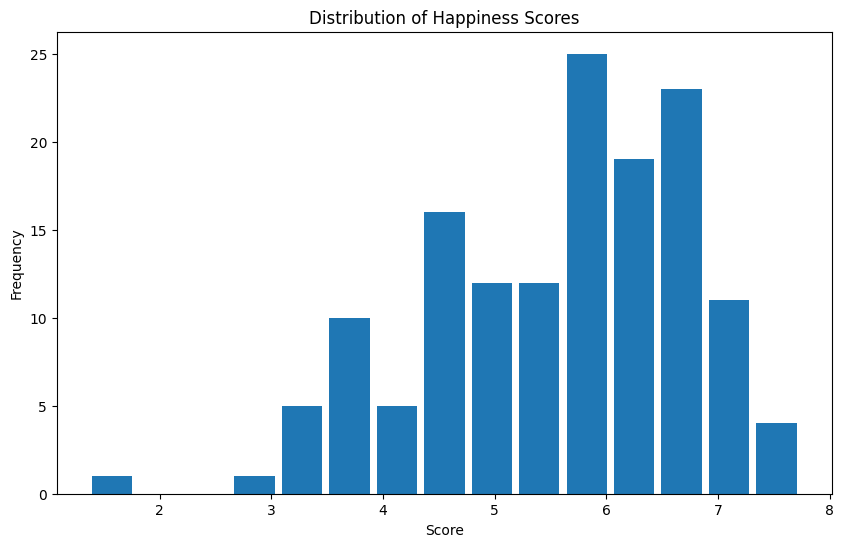

In [13]:
plt.figure(figsize=(10,6))
plt.hist(
    df["Happiness Score"],
    bins=15,
    rwidth=0.85
)
plt.title("Distribution of Happiness Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

Interpretation:

The histogram shows that happiness scores are concentrated primarily between **5 and 7**, indicating that most countries report moderate to high levels of happiness.

Only a few countries fall at the extreme lower end (below 3), while very few achieve exceptionally high happiness scores close to 8. This suggests that extreme happiness or extreme unhappiness is relatively uncommon, with the majority of countries clustered around the middle-to-upper range.

##**Top 10 Happiest Countries**

This section identifies the countries with the highest happiness scores in the World Happiness Report 2025.

Ranking countries based on their happiness scores provides insight into the nations that perform exceptionally well in terms of overall well-being and quality of life. These rankings serve as a useful starting point for exploring the factors that contribute to higher levels of happiness.

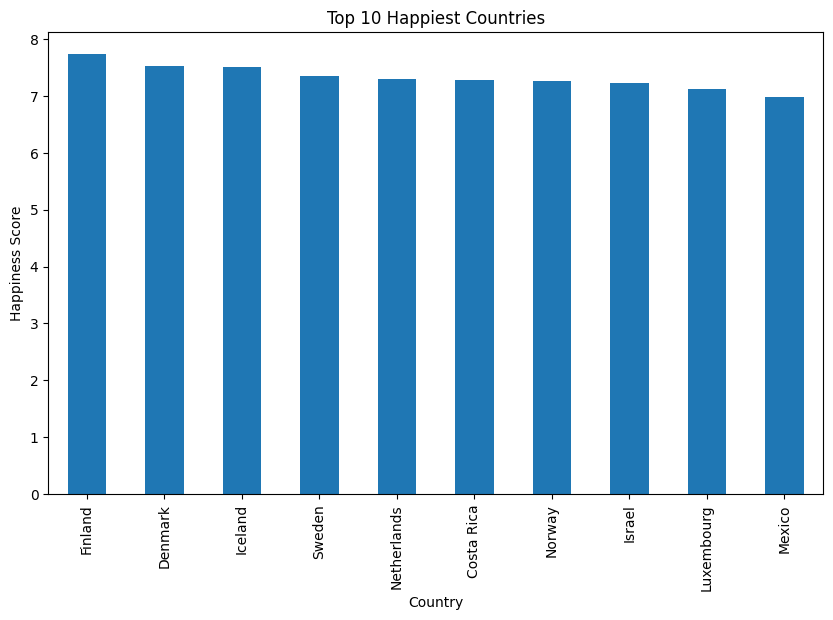

In [14]:
country_score = df.groupby("Country")["Happiness Score"].mean().sort_values(ascending=False)
top_songs=country_score.head(10)
plt.figure(figsize=(10,6))
top_songs.plot(kind='bar')
plt.title("Top 10 Happiest Countries")
plt.xlabel("Country")
plt.ylabel("Happiness Score")
plt.show()

Interpretation:

The visualization shows that **Finland** ranks as the happiest country in the dataset, with a happiness score of approximately **7.74**.

The top ten positions are largely occupied by **Nordic countries**, including Denmark, Iceland, Sweden, and Norway, which consistently report high levels of happiness. Costa Rica, Israel, Luxembourg, and Mexico also appear among the top-ranked countries.

Overall, the difference in happiness scores among the top ten countries is relatively small, indicating that these nations share similarly high levels of well-being.

##**Bottom 10 Happiest Countries**

While the previous section highlighted the happiest countries, this analysis focuses on the countries with the lowest happiness scores.

Examining the lower end of the happiness spectrum helps identify countries facing greater challenges in overall well-being and provides a basis for comparing the factors that influence happiness across different regions.

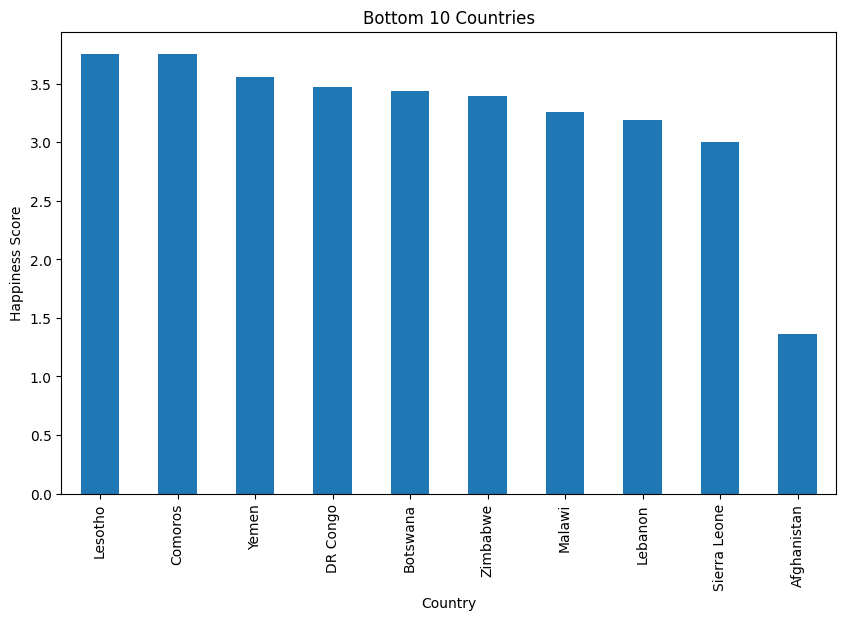

In [15]:
bottom_songs=country_score.tail(10)
plt.figure(figsize=(10,6))
bottom_songs.plot(kind='bar')
plt.title("Bottom 10 Countries")
plt.xlabel("Country")
plt.ylabel("Happiness Score")
plt.show()

Interpretation:

The visualization shows that **Afghanistan** has the lowest happiness score in the dataset, with a score of approximately **1.36**, making it a clear outlier compared to the other countries.

The remaining countries in the bottom ten, including Sierra Leone, Lebanon, Malawi, Zimbabwe, Botswana, DR Congo, Yemen, Comoros, and Lesotho, have happiness scores ranging between approximately **3.0** and **3.8**.

Compared with the top-ranked countries, the difference in happiness scores is substantial, highlighting the wide variation in well-being across different nations.

##**Contribution of Each Factor**

The World Happiness Report estimates how different factors contribute to the happiness score of each country.

This visualization compares the average contribution of these factors across all countries in the dataset, helping identify which factors generally have higher contribution values.

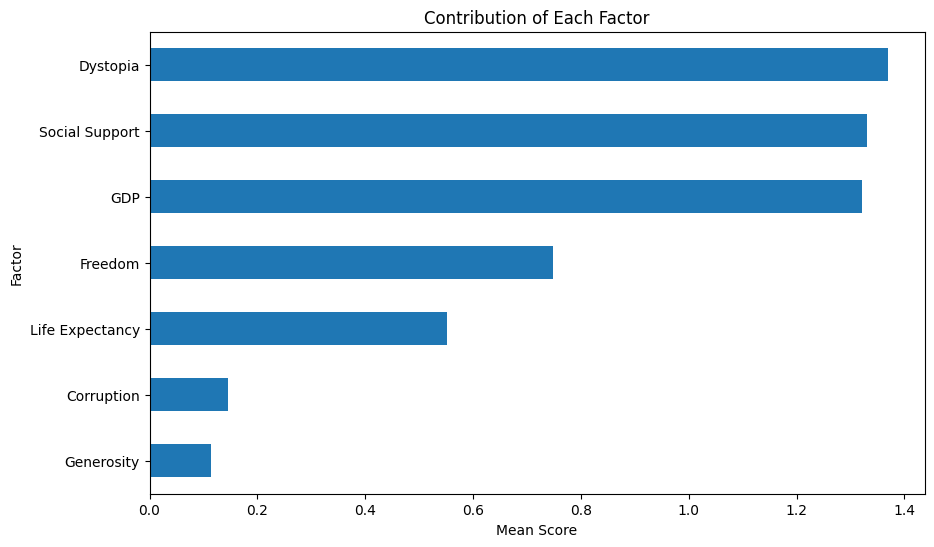

In [16]:
factors = ['GDP','Social Support','Life Expectancy','Freedom','Generosity','Corruption','Dystopia']

contribution=df[factors].mean()
plt.figure(figsize=(10,6))
contribution.sort_values().plot(kind="barh")
plt.title("Contribution of Each Factor")
plt.ylabel("Factor")
plt.xlabel("Mean Score")
plt.show()

Interpretation:

The chart shows that **Dystopia**, **Social Support**, and **GDP** have the highest average contribution values among all the measured factors.

**Freedom** and **Life Expectancy** contribute moderately, while **Generosity** and **Perceptions of Corruption** have comparatively smaller average contribution values.

Overall, economic conditions and strong social relationships appear to contribute more consistently to national happiness than generosity or corruption alone.

##**Correlation Analysis**

Correlation analysis measures how strongly each factor is associated with the Happiness Score.

The correlation coefficient ranges from **-1 to +1**:
- **+1** → Perfect positive relationship
- **0** → No relationship
- **-1** → Perfect negative relationship

A higher positive correlation indicates that countries with higher values of that factor generally tend to have higher happiness scores.

In [30]:
correlation = df[[
    "Happiness Score",
    "GDP",
    "Social Support",
    "Life Expectancy",
    "Freedom",
    "Generosity",
    "Corruption",
    "Dystopia"
]].corr()
print(correlation["Happiness Score"].sort_values(ascending=False))

Happiness Score    1.000000
Social Support     0.817428
GDP                0.763781
Life Expectancy    0.714674
Freedom            0.632267
Dystopia           0.492648
Corruption         0.416878
Generosity         0.047864
Name: Happiness Score, dtype: float64


Interpretation:

The results show that **Social Support (0.82)** has the strongest positive correlation with the Happiness Score, making it the factor most closely associated with happiness in this dataset.

Other factors such as **GDP (0.76)** and **Life Expectancy (0.71)** also exhibit strong positive relationships, suggesting that wealth and health are important contributors to overall well-being.

**Freedom (0.63)** and **Dystopia (0.49)** show moderate positive correlations, while **Generosity (0.05)** has only a very weak relationship with happiness.

Overall, countries with stronger social support systems, higher income levels, and better life expectancy generally report higher happiness scores.

##**Correlation Heatmap**

A heatmap provides a visual representation of the correlation matrix, making it easier to identify strong and weak relationships between variables.

Darker shades of red indicate stronger positive correlations, while lighter colors represent weaker relationships.

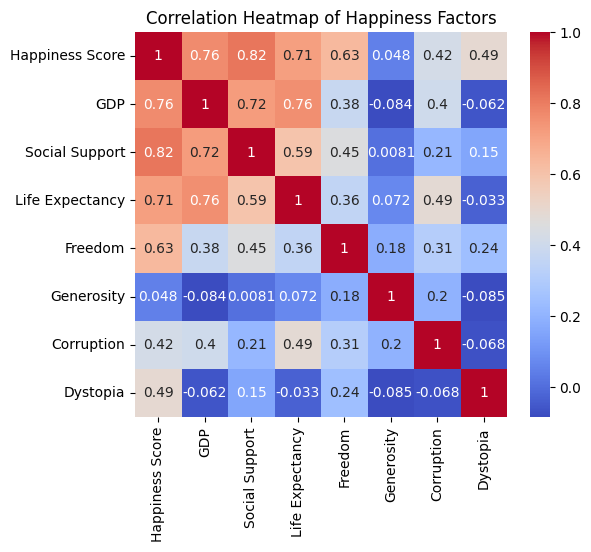

In [37]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Happiness Factors")
plt.show()

Interpretation:

The heatmap confirms the numerical correlation analysis by clearly highlighting the strongest relationships.

The Happiness Score is most strongly associated with **Social Support**, **GDP**, and **Life Expectancy**, which appear as the darkest red regions in the matrix.

In contrast, **Generosity** has a much weaker correlation with the Happiness Score, indicating that it is less closely associated with national happiness compared to the other factors.

The visualization also helps identify relationships among the explanatory factors themselves, making it easier to understand how these variables interact within the dataset.

##**Ranking of Happiness Factors**

After calculating the correlation values, the factors are ranked from the strongest to the weakest based on their relationship with the Happiness Score.

This ranking provides a quick summary of which variables are most closely associated with happiness across different countries.

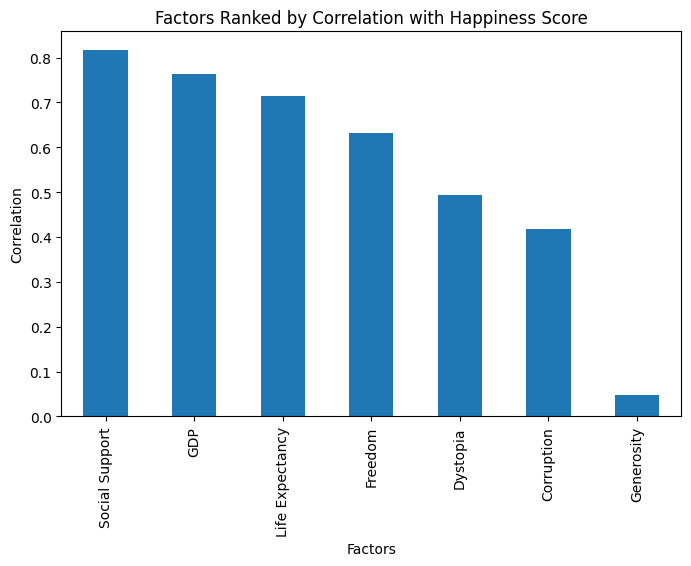

In [26]:
feature_ranking = (
    correlation["Happiness Score"]
    .drop(["Happiness Score", "upperwhisker", "lowerwhisker"])
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

feature_ranking.plot(kind="bar")

plt.title("Factors Ranked by Correlation with Happiness Score")
plt.xlabel("Factors")
plt.ylabel("Correlation")
plt.show()

Interpretation:

The ranking shows that **Social Support** has the strongest correlation with the Happiness Score, followed by **GDP** and **Life Expectancy**.

These results suggest that countries with stronger social connections, healthier populations, and better economic conditions generally report higher levels of happiness.

On the other hand, **Generosity** exhibits the weakest correlation, indicating that although generosity is a positive social trait, it has a relatively small direct association with overall happiness in this dataset.

Overall, the ranking highlights that social well-being and economic stability are more strongly linked to happiness than generosity or perceptions of corruption.

##**Can Money Buy Happiness?**

One of the most common questions is whether wealth leads to happiness.

This scatter plot explores the relationship between GDP contribution and the Happiness Score, allowing us to observe whether countries with higher GDP generally report greater happiness.

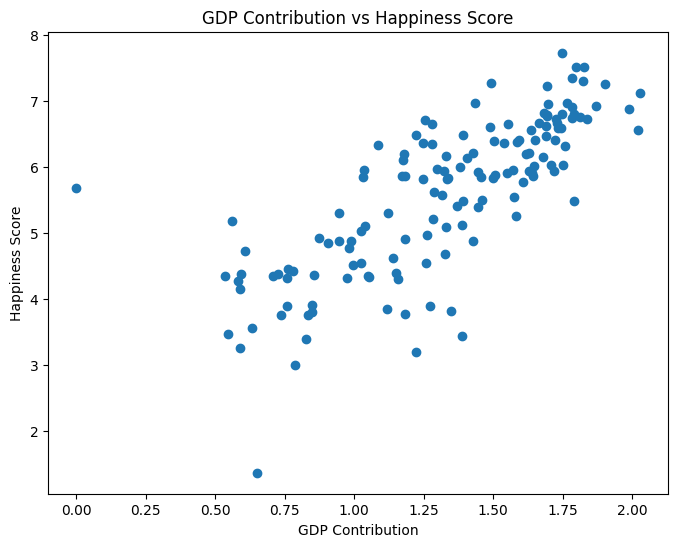

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(df["GDP"], df["Happiness Score"])

plt.title("GDP Contribution vs Happiness Score")
plt.xlabel("GDP Contribution")
plt.ylabel("Happiness Score")

plt.show()

Interpretation:

The scatter plot reveals a clear positive trend between GDP contribution and the Happiness Score.

Countries with higher GDP generally tend to report higher levels of happiness, indicating that economic prosperity is an important contributor to overall well-being.

However, the points are not perfectly aligned, showing that GDP alone does not determine happiness. Countries with similar GDP values can still have different happiness scores due to other influencing factors such as social support, freedom, life expectancy, and governance.

This suggests that while money contributes to happiness, it is only one part of a much broader picture.

##**Final Insights**

From this analysis, several important observations emerged:

- Happiness is strongly associated with Social Support, GDP, and Life Expectancy.
- Countries with stronger economies generally report higher happiness scores.
- Social Support is the most influential factor among all variables analyzed.
- Freedom also contributes positively to happiness, although to a lesser extent than GDP and Social Support.
- Generosity shows only a weak direct relationship with Happiness Score.
- Multiple factors work together to influence national happiness rather than a single variable.

##**Conclusion**

This project explored the World Happiness Report 2025 using Python, NumPy, Pandas, and data visualization libraries.

Through data cleaning, exploratory data analysis, correlation analysis, and visualizations, the project identified the key factors associated with national happiness. The findings indicate that social support, economic prosperity, and healthy life expectancy have the strongest relationships with happiness, while generosity alone has a relatively weak association.

Overall, the analysis demonstrates that happiness is a multidimensional concept shaped by economic, social, and health-related factors rather than wealth alone.